# Graphs for CBL Project
This file contains the graphs, download the graphs from here for the best quality
please make sure to commit after you have made a change

*** If you want to make graphs with uniform styles as these ones in order to have a continous stlye in reports or presentations, just give the codes here along with your code to AI. It will unify the stlye automatically

## Power - Time

### Data comparison of the entire year

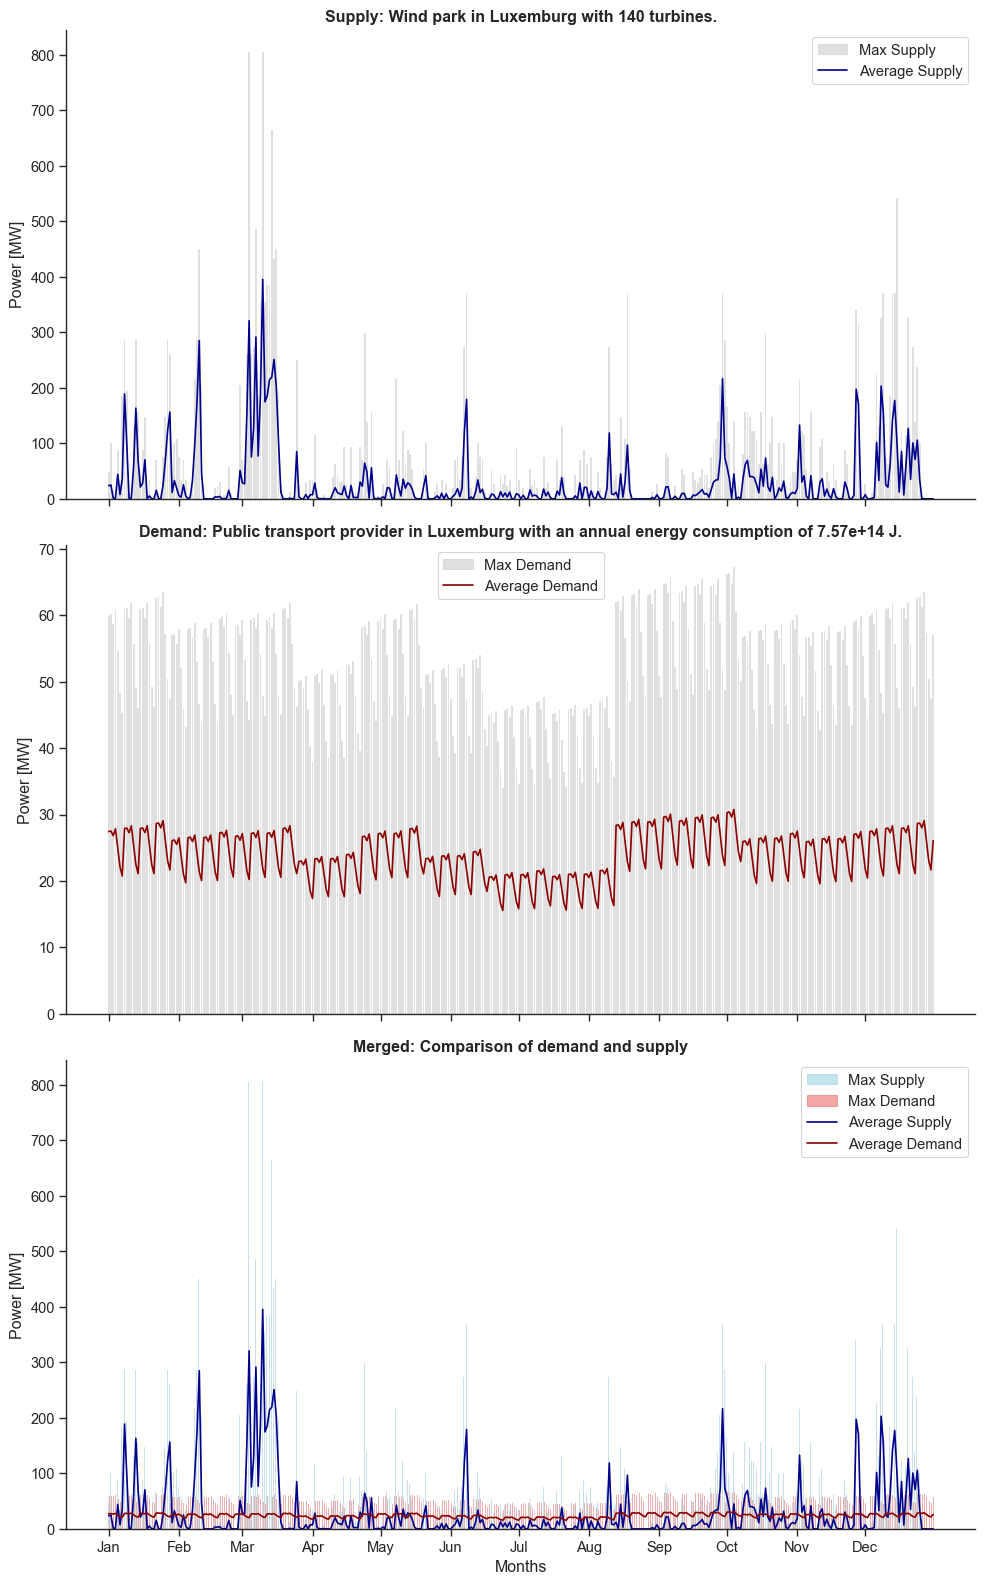

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Apply academic style using Seaborn
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# 2. Load the datasets
df_supply = pd.read_csv("Team38_supply.csv", skipinitialspace=True)
df_demand = pd.read_csv("Team38_demand.csv", skipinitialspace=True)

df_supply.columns = df_supply.columns.str.strip()
df_demand.columns = df_demand.columns.str.strip()

# 3. Group by discrete Days (matches the previous detailed daily representation spanning 365 Days)
df_supply['Time (Days)'] = (df_supply['time [s]'] // 86400).astype(int)
df_demand['Time (Days)'] = (df_demand['time [s]'] // 86400).astype(int)

# This preserves the full year density (365 exact daily points with Max backgrounds!)
supply_agg = df_supply.groupby('Time (Days)', observed=False)['power [MW]'].agg(Mean='mean', Max='max').reset_index()
demand_agg = df_demand.groupby('Time (Days)', observed=False)['power [MW]'].agg(Mean='mean', Max='max').reset_index()

# Extract merged frames
supply_agg['Type'] = 'Supply'
demand_agg['Type'] = 'Demand'
merged_agg = pd.concat([supply_agg, demand_agg], ignore_index=True)

# 4. Generate the Subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 16), sharex=True)

# Subplot 1: Supply explicitly with 0 linewidth to prevent border crush on 365 bars
sns.barplot(data=supply_agg, x='Time (Days)', y='Max', color='lightgray', alpha=0.7, linewidth=0, ax=axes[0])
sns.lineplot(data=supply_agg, x='Time (Days)', y='Mean', color='darkblue', legend=False, errorbar=None, ax=axes[0])
axes[0].set_title('Supply: Wind park in Luxemburg with 140 turbines.', weight='bold')
axes[0].set_ylabel('Power [MW]')
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='lightgray', alpha=0.7),
    plt.Line2D([], [], color='darkblue')
], labels=['Max Supply', 'Average Supply'])

# Subplot 2: Demand
sns.barplot(data=demand_agg, x='Time (Days)', y='Max', color='lightgray', alpha=0.7, linewidth=0, ax=axes[1])
sns.lineplot(data=demand_agg, x='Time (Days)', y='Mean', color='darkred', legend=False, errorbar=None, ax=axes[1])
axes[1].set_title('Demand: Public transport provider in Luxemburg with an annual energy consumption of 7.57e+14 J.', weight='bold')
axes[1].set_ylabel('Power [MW]')
axes[1].legend(handles=[
    plt.Rectangle((0,0),1,1, color='lightgray', alpha=0.7),
    plt.Line2D([], [], color='darkred')
], labels=['Max Demand', 'Average Demand'])

# Subplot 3: Merged Panel
sns.barplot(data=merged_agg, x='Time (Days)', y='Max', hue='Type', palette={'Supply': 'lightblue', 'Demand': 'lightcoral'}, alpha=0.7, linewidth=0, ax=axes[2])
sns.lineplot(data=merged_agg, x='Time (Days)', y='Mean', hue='Type', palette={'Supply': 'darkblue', 'Demand': 'darkred'}, legend=False, errorbar=None, ax=axes[2])
axes[2].set_title('Merged: Comparison of demand and supply', weight='bold')
axes[2].set_xlabel('Months')  # Set explicitly
axes[2].set_ylabel('Power [MW]')
axes[2].legend(handles=[
    plt.Rectangle((0,0),1,1, color='lightblue', alpha=0.7),
    plt.Rectangle((0,0),1,1, color='lightcoral', alpha=0.7),
    plt.Line2D([], [], color='darkblue'),
    plt.Line2D([], [], color='darkred')
], labels=['Max Supply', 'Max Demand', 'Average Supply', 'Average Demand'])

# Format x-axis accurately to display 'Month' labels directly over the raw 365 Days
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for ax in axes:
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_names)

sns.despine(fig)
plt.tight_layout()
plt.show()

### Days

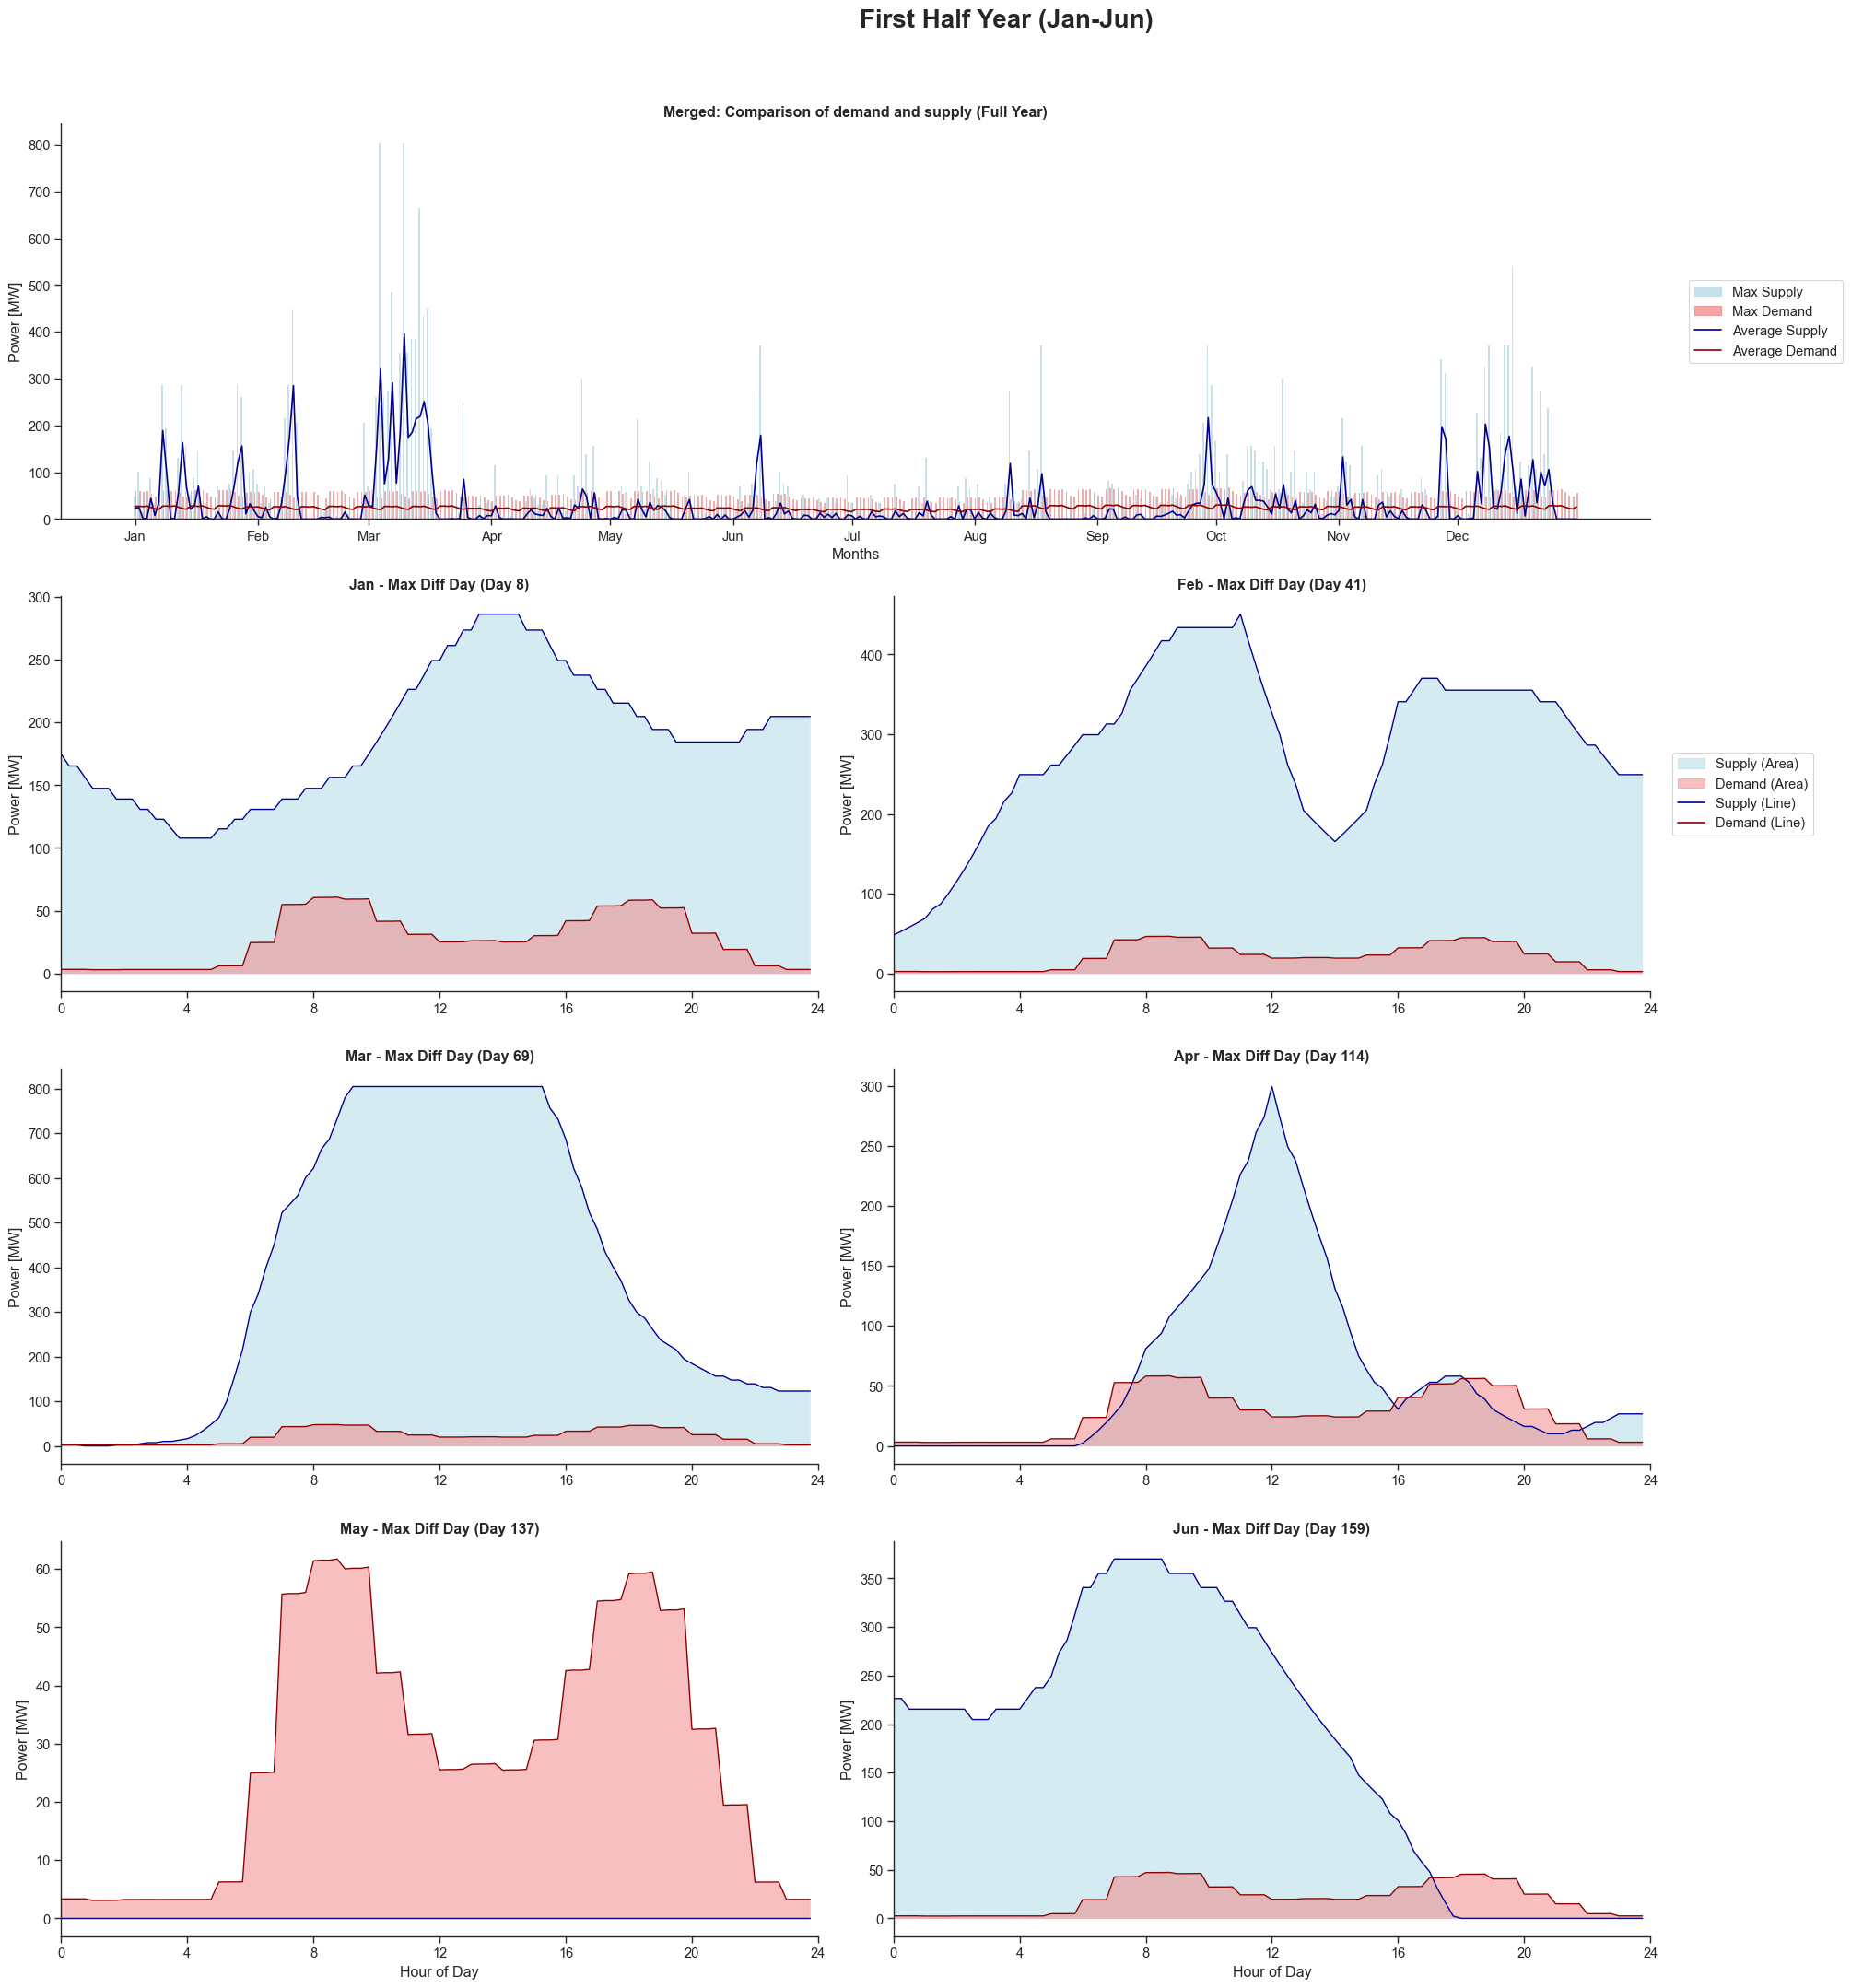

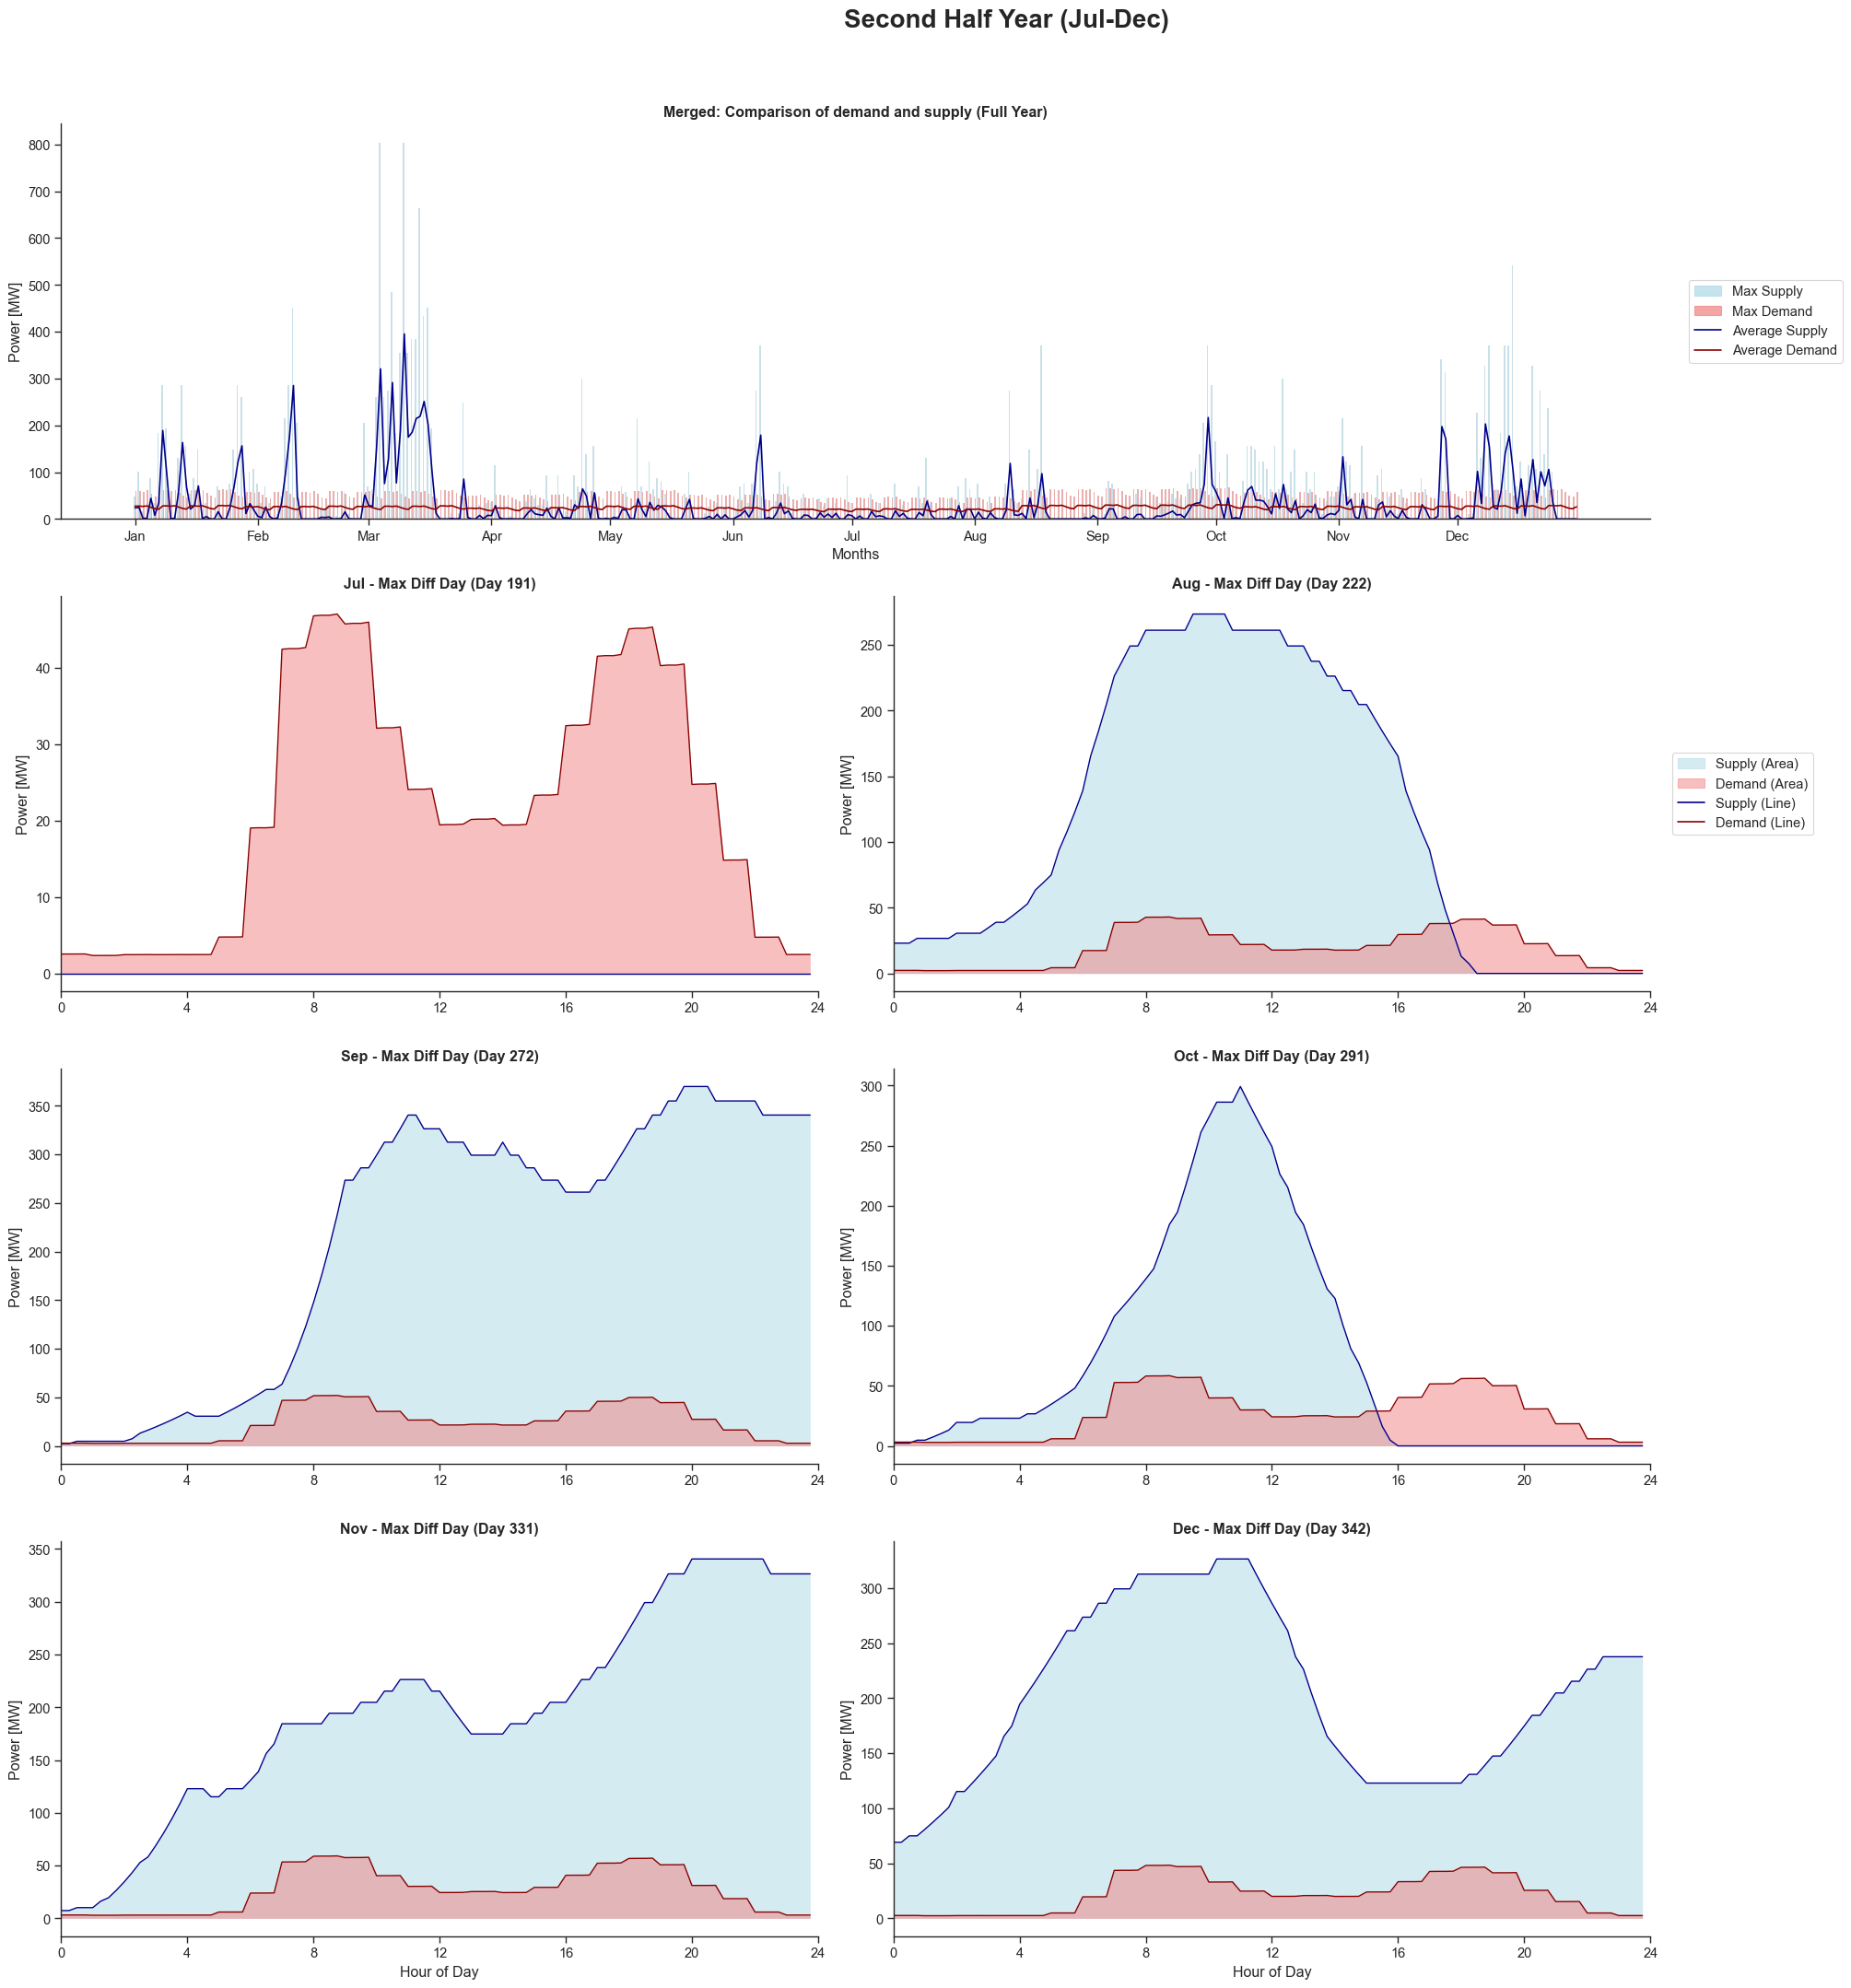

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def create_half_year_figure_max_diff_day(month_indices, fig_title):
    # Enlarge the plot to make it clear for the subplots
    fig = plt.figure(figsize=(22, 22))
    gs = fig.add_gridspec(4, 2)
    
    # Identify the day with the absolute max difference in mean supply and demand
    pivot_diff = merged_agg.pivot(index='Time (Days)', columns='Type', values='Mean')
    pivot_diff['Abs_Diff'] = abs(pivot_diff['Supply'] - pivot_diff['Demand'])
    
    # --- Top Subplot: Full Year Comparison ---
    ax_top = fig.add_subplot(gs[0, :])
    
    sns.barplot(data=merged_agg, x='Time (Days)', y='Max', hue='Type', palette={'Supply': 'lightblue', 'Demand': 'lightcoral'}, alpha=0.7, linewidth=0, ax=ax_top)
    sns.lineplot(data=merged_agg, x='Time (Days)', y='Mean', hue='Type', palette={'Supply': 'darkblue', 'Demand': 'darkred'}, legend=False, errorbar=None, ax=ax_top)
    
    ax_top.set_title('Merged: Comparison of demand and supply (Full Year)', weight='bold')
    ax_top.set_xlabel('Months')
    ax_top.set_ylabel('Power [MW]')
    ax_top.legend(handles=[
        plt.Rectangle((0,0),1,1, color='lightblue', alpha=0.7),
        plt.Rectangle((0,0),1,1, color='lightcoral', alpha=0.7),
        plt.Line2D([], [], color='darkblue'),
        plt.Line2D([], [], color='darkred')
    ], labels=['Max Supply', 'Max Demand', 'Average Supply', 'Average Demand'], loc='center left', bbox_to_anchor=(1.02, 0.5))
    
    # Safely handle 'month_starts' matching your variables length
    if len(month_starts) > 12:
        ax_top.set_xticks(month_starts[:-1])
    else:
        ax_top.set_xticks(month_starts)
    ax_top.set_xticklabels(month_names)

    # --- Small Subplots: The Max Difference Day for Each Month ---
    for i, m_idx in enumerate(month_indices):
        row = (i // 2) + 1
        col = i % 2
        ax = fig.add_subplot(gs[row, col])
        
        start_day = month_starts[m_idx]
        if m_idx + 1 < len(month_starts):
            end_day = month_starts[m_idx+1] - 1
        else:
            end_day = 364 # Fallback logic for December
            
        # Find the single day in this month where |Supply - Demand| is highest
        month_diffs = pivot_diff.loc[start_day:end_day]
        max_diff_day = month_diffs['Abs_Diff'].idxmax()
        
        # Extract the exact 24 hours of data for that max difference day
        day_supply = df_supply[df_supply['Time (Days)'] == max_diff_day]
        day_demand = df_demand[df_demand['Time (Days)'] == max_diff_day]
        
        # Convert absolute time in dataset to hours (0 through 24)
        x_supply_hours = (day_supply['time [s]'] - max_diff_day * 86400) / 3600.0
        x_demand_hours = (day_demand['time [s]'] - max_diff_day * 86400) / 3600.0
        
        # Plot Under-Shading Support
        ax.fill_between(x_supply_hours, day_supply['power [MW]'], color='lightblue', alpha=0.5, linewidth=0)
        ax.fill_between(x_demand_hours, day_demand['power [MW]'], color='lightcoral', alpha=0.5, linewidth=0)
        
        # Plot Precise Foreground Lines
        ax.plot(x_supply_hours, day_supply['power [MW]'], color='darkblue', linewidth=1)
        ax.plot(x_demand_hours, day_demand['power [MW]'], color='darkred', linewidth=1)
        
        # Title denotes the exact day of the year chosen
        ax.set_title(f'{month_names[m_idx]} - Max Diff Day (Day {max_diff_day + 1})', weight='bold')
        
        # Fix X-Limits directly to hours 
        ax.set_xlim(0, 24)
        ax.set_xticks(range(0, 25, 4))
        
        if i >= 4:
            ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Power [MW]')
        
        # Plot outer legend only once
        if i == 1:
            ax.legend(handles=[
                plt.Rectangle((0,0),1,1, color='lightblue', alpha=0.5),
                plt.Rectangle((0,0),1,1, color='lightcoral', alpha=0.5),
                plt.Line2D([], [], color='darkblue'),
                plt.Line2D([], [], color='darkred')
            ], labels=['Supply (Area)', 'Demand (Area)', 'Supply (Line)', 'Demand (Line)'], 
               loc='center left', bbox_to_anchor=(1.02, 0.5))
            
    fig.suptitle(fig_title, weight='bold', fontsize=20)
    sns.despine(fig)
    plt.tight_layout(rect=[0, 0, 0.92, 0.96])
    plt.show()

create_half_year_figure_max_diff_day([0, 1, 2, 3, 4, 5], 'First Half Year (Jan-Jun)')
create_half_year_figure_max_diff_day([6, 7, 8, 9, 10, 11], 'Second Half Year (Jul-Dec)')


### Weeks

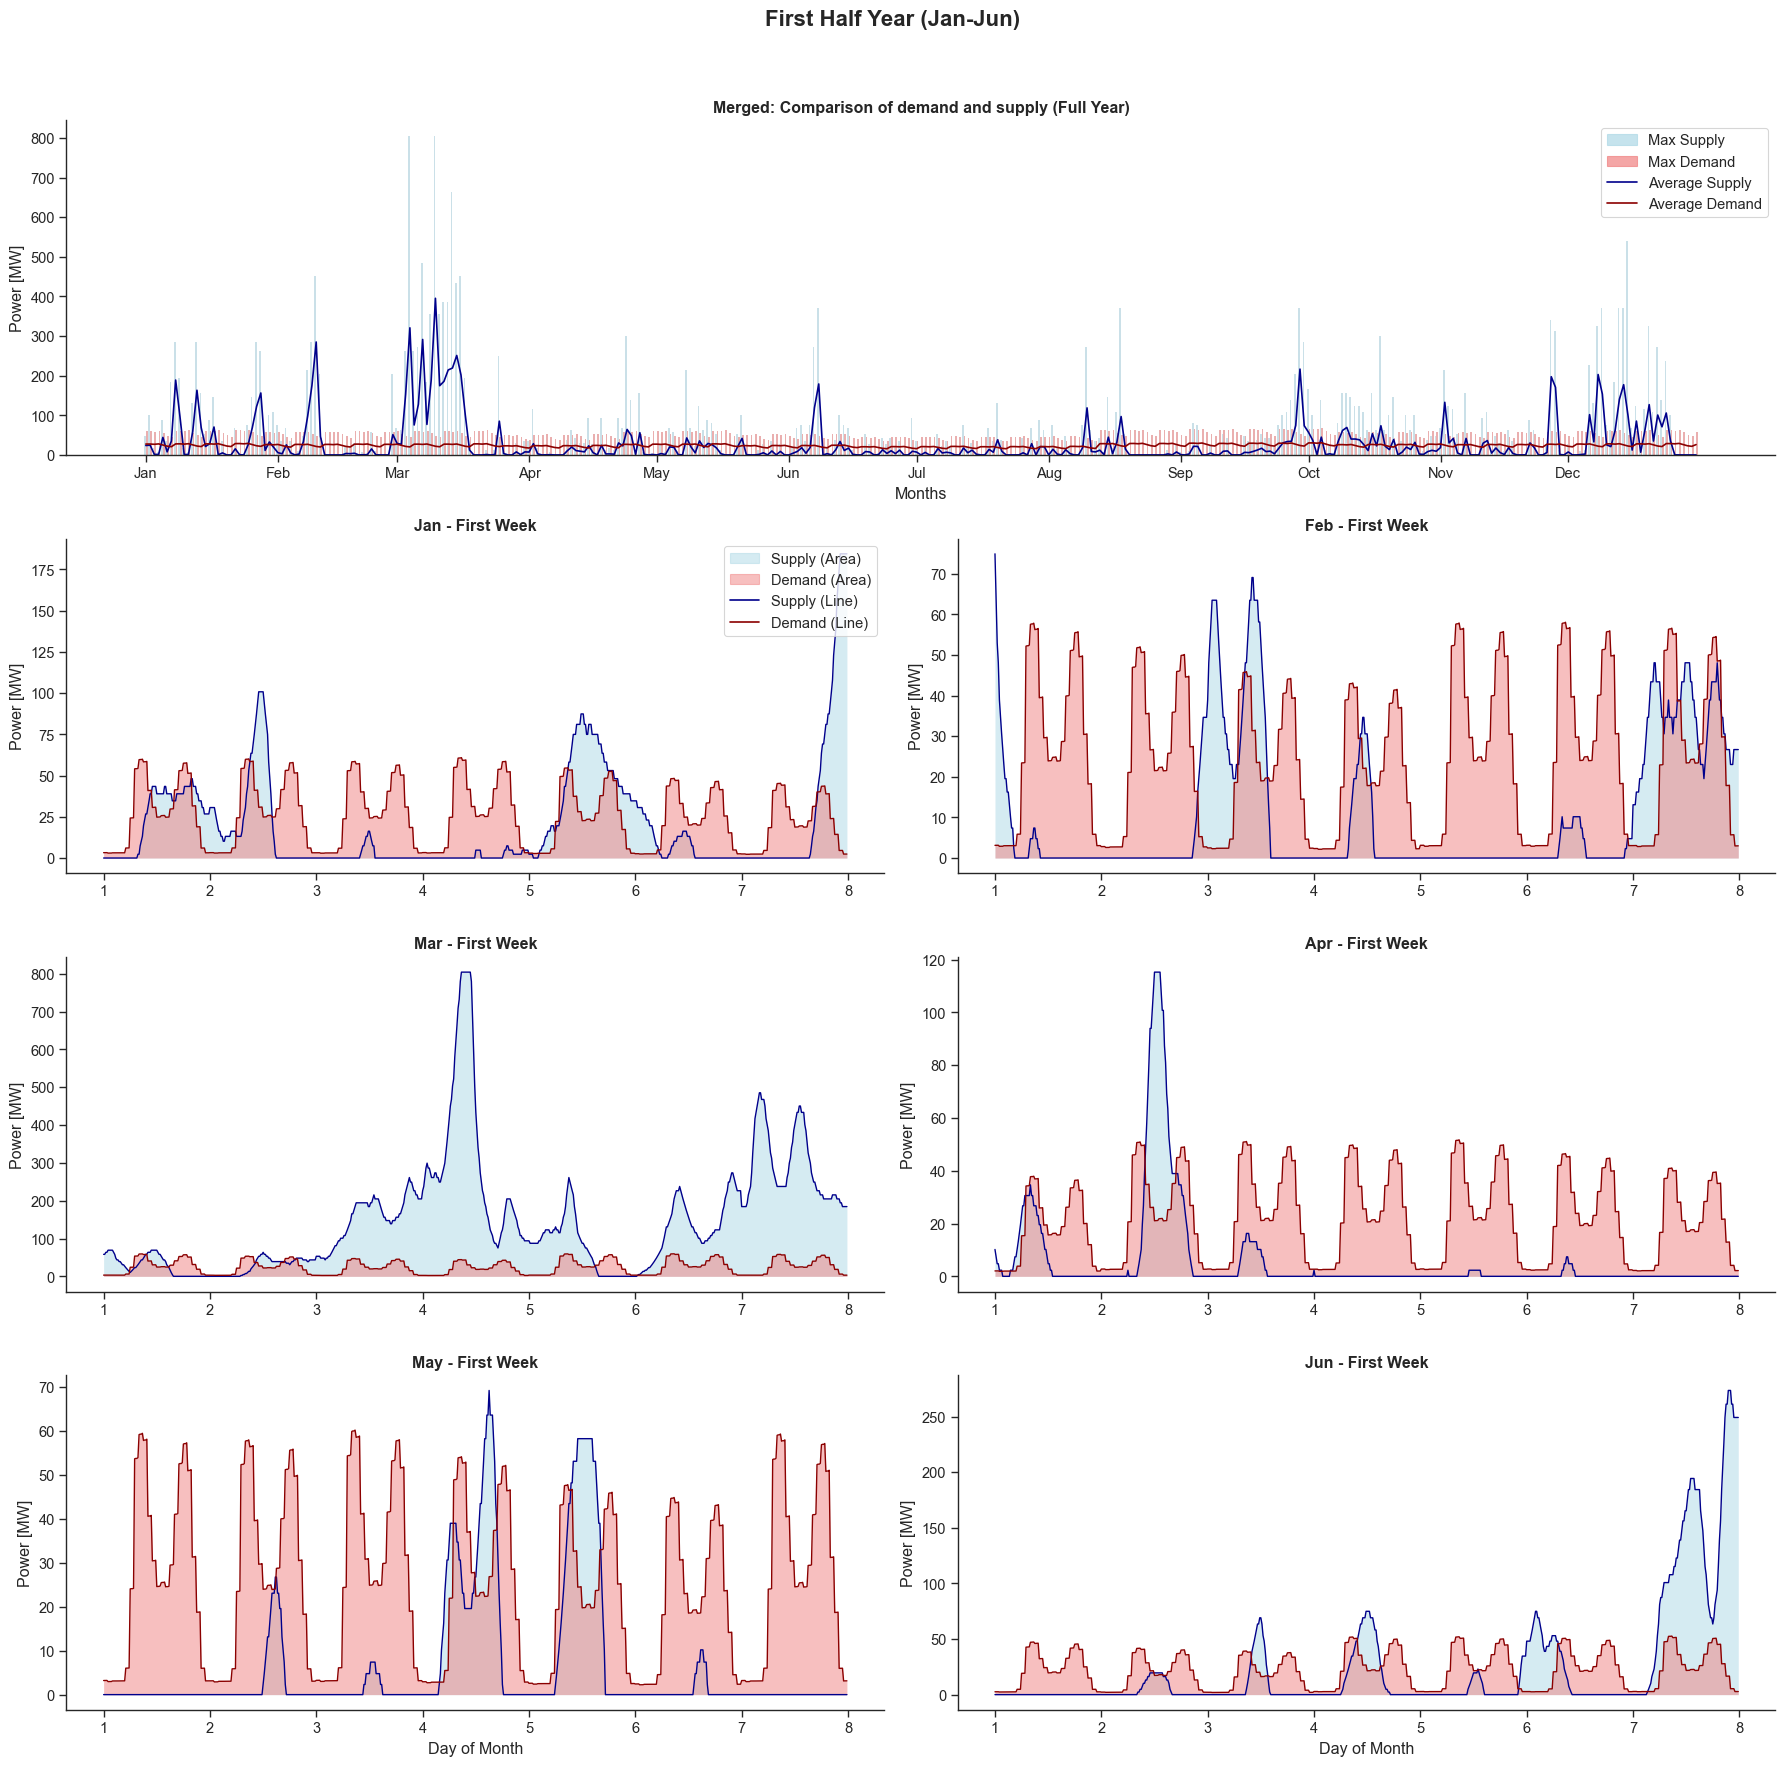

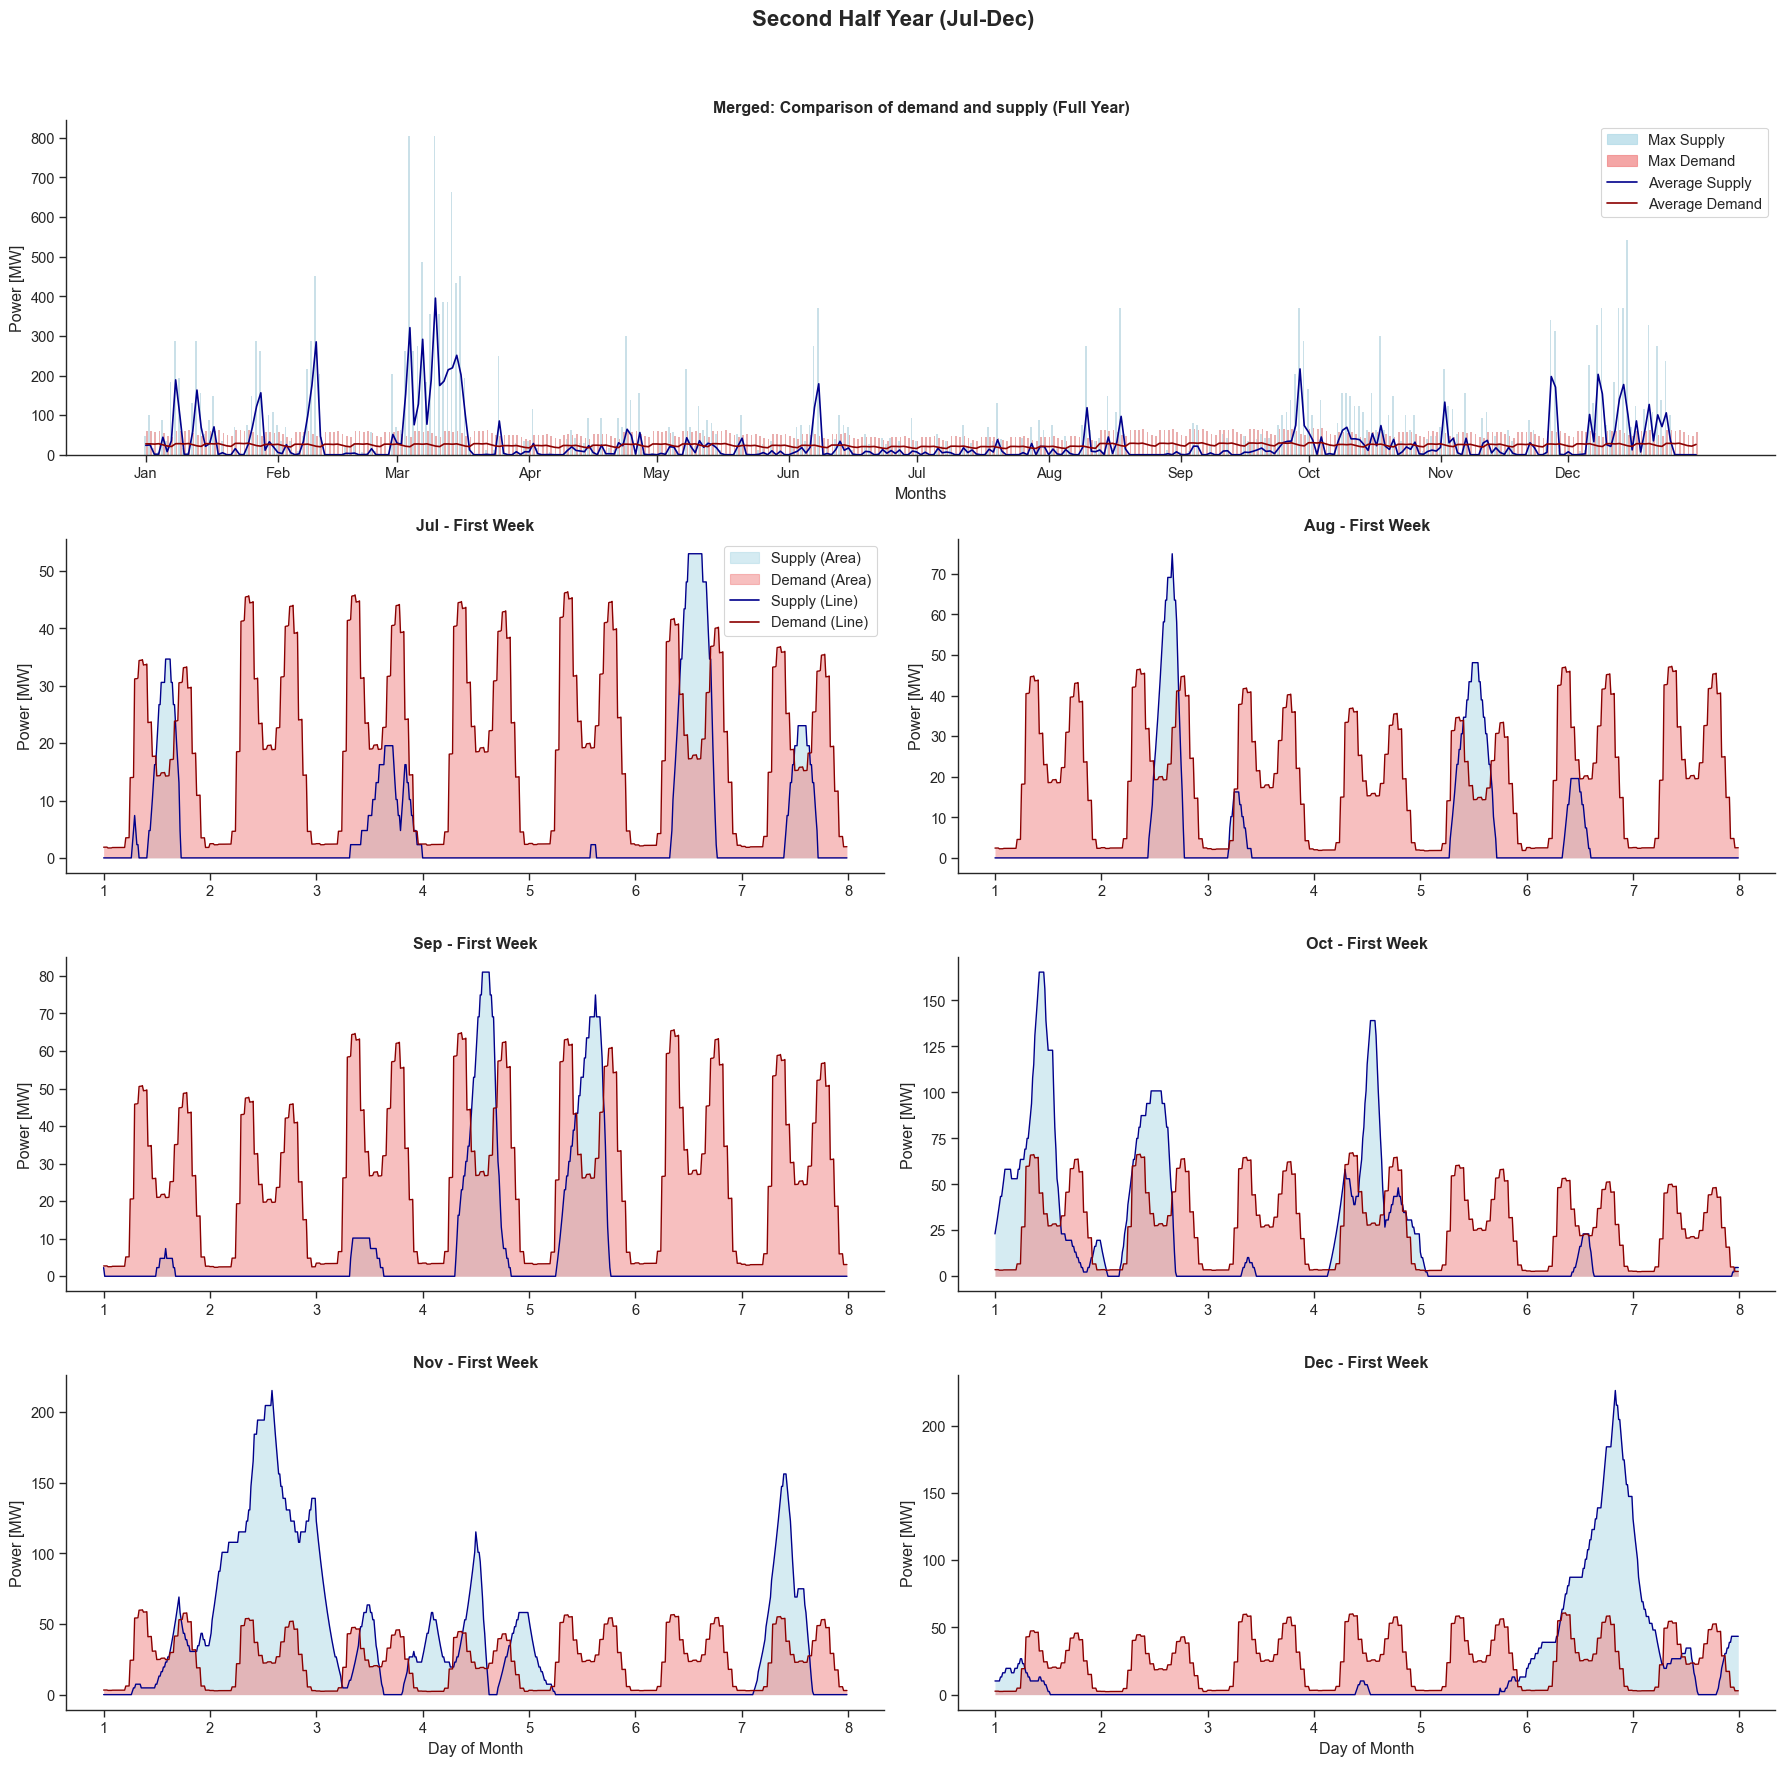

In [ ]:


# 1. Apply academic style using Seaborn
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# 2. Load the datasets
df_supply = pd.read_csv("Team38_supply.csv", skipinitialspace=True)
df_demand = pd.read_csv("Team38_demand.csv", skipinitialspace=True)

df_supply.columns = df_supply.columns.str.strip()
df_demand.columns = df_demand.columns.str.strip()

# 3. Group by discrete Days for the top overall comparison plot
df_supply['Time (Days)'] = (df_supply['time [s]'] // 86400).astype(int)
df_demand['Time (Days)'] = (df_demand['time [s]'] // 86400).astype(int)

supply_agg = df_supply.groupby('Time (Days)', observed=False)['power [MW]'].agg(Mean='mean', Max='max').reset_index()
demand_agg = df_demand.groupby('Time (Days)', observed=False)['power [MW]'].agg(Mean='mean', Max='max').reset_index()

supply_agg['Type'] = 'Supply'
demand_agg['Type'] = 'Demand'
merged_agg = pd.concat([supply_agg, demand_agg], ignore_index=True)

month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def create_half_year_figure(month_indices, fig_title):
    fig = plt.figure(figsize=(18, 18))
    gs = fig.add_gridspec(4, 2)
    
    # --- Top Subplot: Full Year Comparison ---
    ax_top = fig.add_subplot(gs[0, :])
    
    sns.barplot(data=merged_agg, x='Time (Days)', y='Max', hue='Type', palette={'Supply': 'lightblue', 'Demand': 'lightcoral'}, alpha=0.7, linewidth=0, ax=ax_top)
    sns.lineplot(data=merged_agg, x='Time (Days)', y='Mean', hue='Type', palette={'Supply': 'darkblue', 'Demand': 'darkred'}, legend=False, errorbar=None, ax=ax_top)
    
    ax_top.set_title('Merged: Comparison of demand and supply (Full Year)', weight='bold')
    ax_top.set_xlabel('Months')
    ax_top.set_ylabel('Power [MW]')
    ax_top.legend(handles=[
        plt.Rectangle((0,0),1,1, color='lightblue', alpha=0.7),
        plt.Rectangle((0,0),1,1, color='lightcoral', alpha=0.7),
        plt.Line2D([], [], color='darkblue'),
        plt.Line2D([], [], color='darkred')
    ], labels=['Max Supply', 'Max Demand', 'Average Supply', 'Average Demand'], loc='upper right')
    
    ax_top.set_xticks(month_starts)
    ax_top.set_xticklabels(month_names)

    # --- Small Subplots: First Week of Each Month ---
    for i, m_idx in enumerate(month_indices):
        row = (i // 2) + 1
        col = i % 2
        ax = fig.add_subplot(gs[row, col])
        
        start_day = month_starts[m_idx]
        end_day = start_day + 6
        
        # Extract 1st week data for current month
        week_supply = df_supply[(df_supply['Time (Days)'] >= start_day) & (df_supply['Time (Days)'] <= end_day)]
        week_demand = df_demand[(df_demand['Time (Days)'] >= start_day) & (df_demand['Time (Days)'] <= end_day)]
        
        # Time in days (relative to day 1 to 7 of that month)
        x_supply = (week_supply['time [s]'] - start_day * 86400) / 86400.0 + 1
        x_demand = (week_demand['time [s]'] - start_day * 86400) / 86400.0 + 1
        
        # Shades under the line plot (using fill_between)
        ax.fill_between(x_supply, week_supply['power [MW]'], color='lightblue', alpha=0.5, linewidth=0)
        ax.fill_between(x_demand, week_demand['power [MW]'], color='lightcoral', alpha=0.5, linewidth=0)
        
        # Foreground lines using exact data (no averages)
        ax.plot(x_supply, week_supply['power [MW]'], color='darkblue', linewidth=1)
        ax.plot(x_demand, week_demand['power [MW]'], color='darkred', linewidth=1)
        
        ax.set_title(f'{month_names[m_idx]} - First Week', weight='bold')
        if i >= 4:
            ax.set_xlabel('Day of Month')
        ax.set_ylabel('Power [MW]')
        
        if i == 0:
            ax.legend(handles=[
                plt.Rectangle((0,0),1,1, color='lightblue', alpha=0.5),
                plt.Rectangle((0,0),1,1, color='lightcoral', alpha=0.5),
                plt.Line2D([], [], color='darkblue'),
                plt.Line2D([], [], color='darkred')
            ], labels=['Supply (Area)', 'Demand (Area)', 'Supply (Line)', 'Demand (Line)'], loc='upper right')
            
    fig.suptitle(fig_title, weight='bold', fontsize=16)
    sns.despine(fig)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# 4. Generate the two figures
create_half_year_figure([0, 1, 2, 3, 4, 5], "First Half Year (Jan-Jun)")
create_half_year_figure([6, 7, 8, 9, 10, 11], "Second Half Year (Jul-Dec)")


### Months

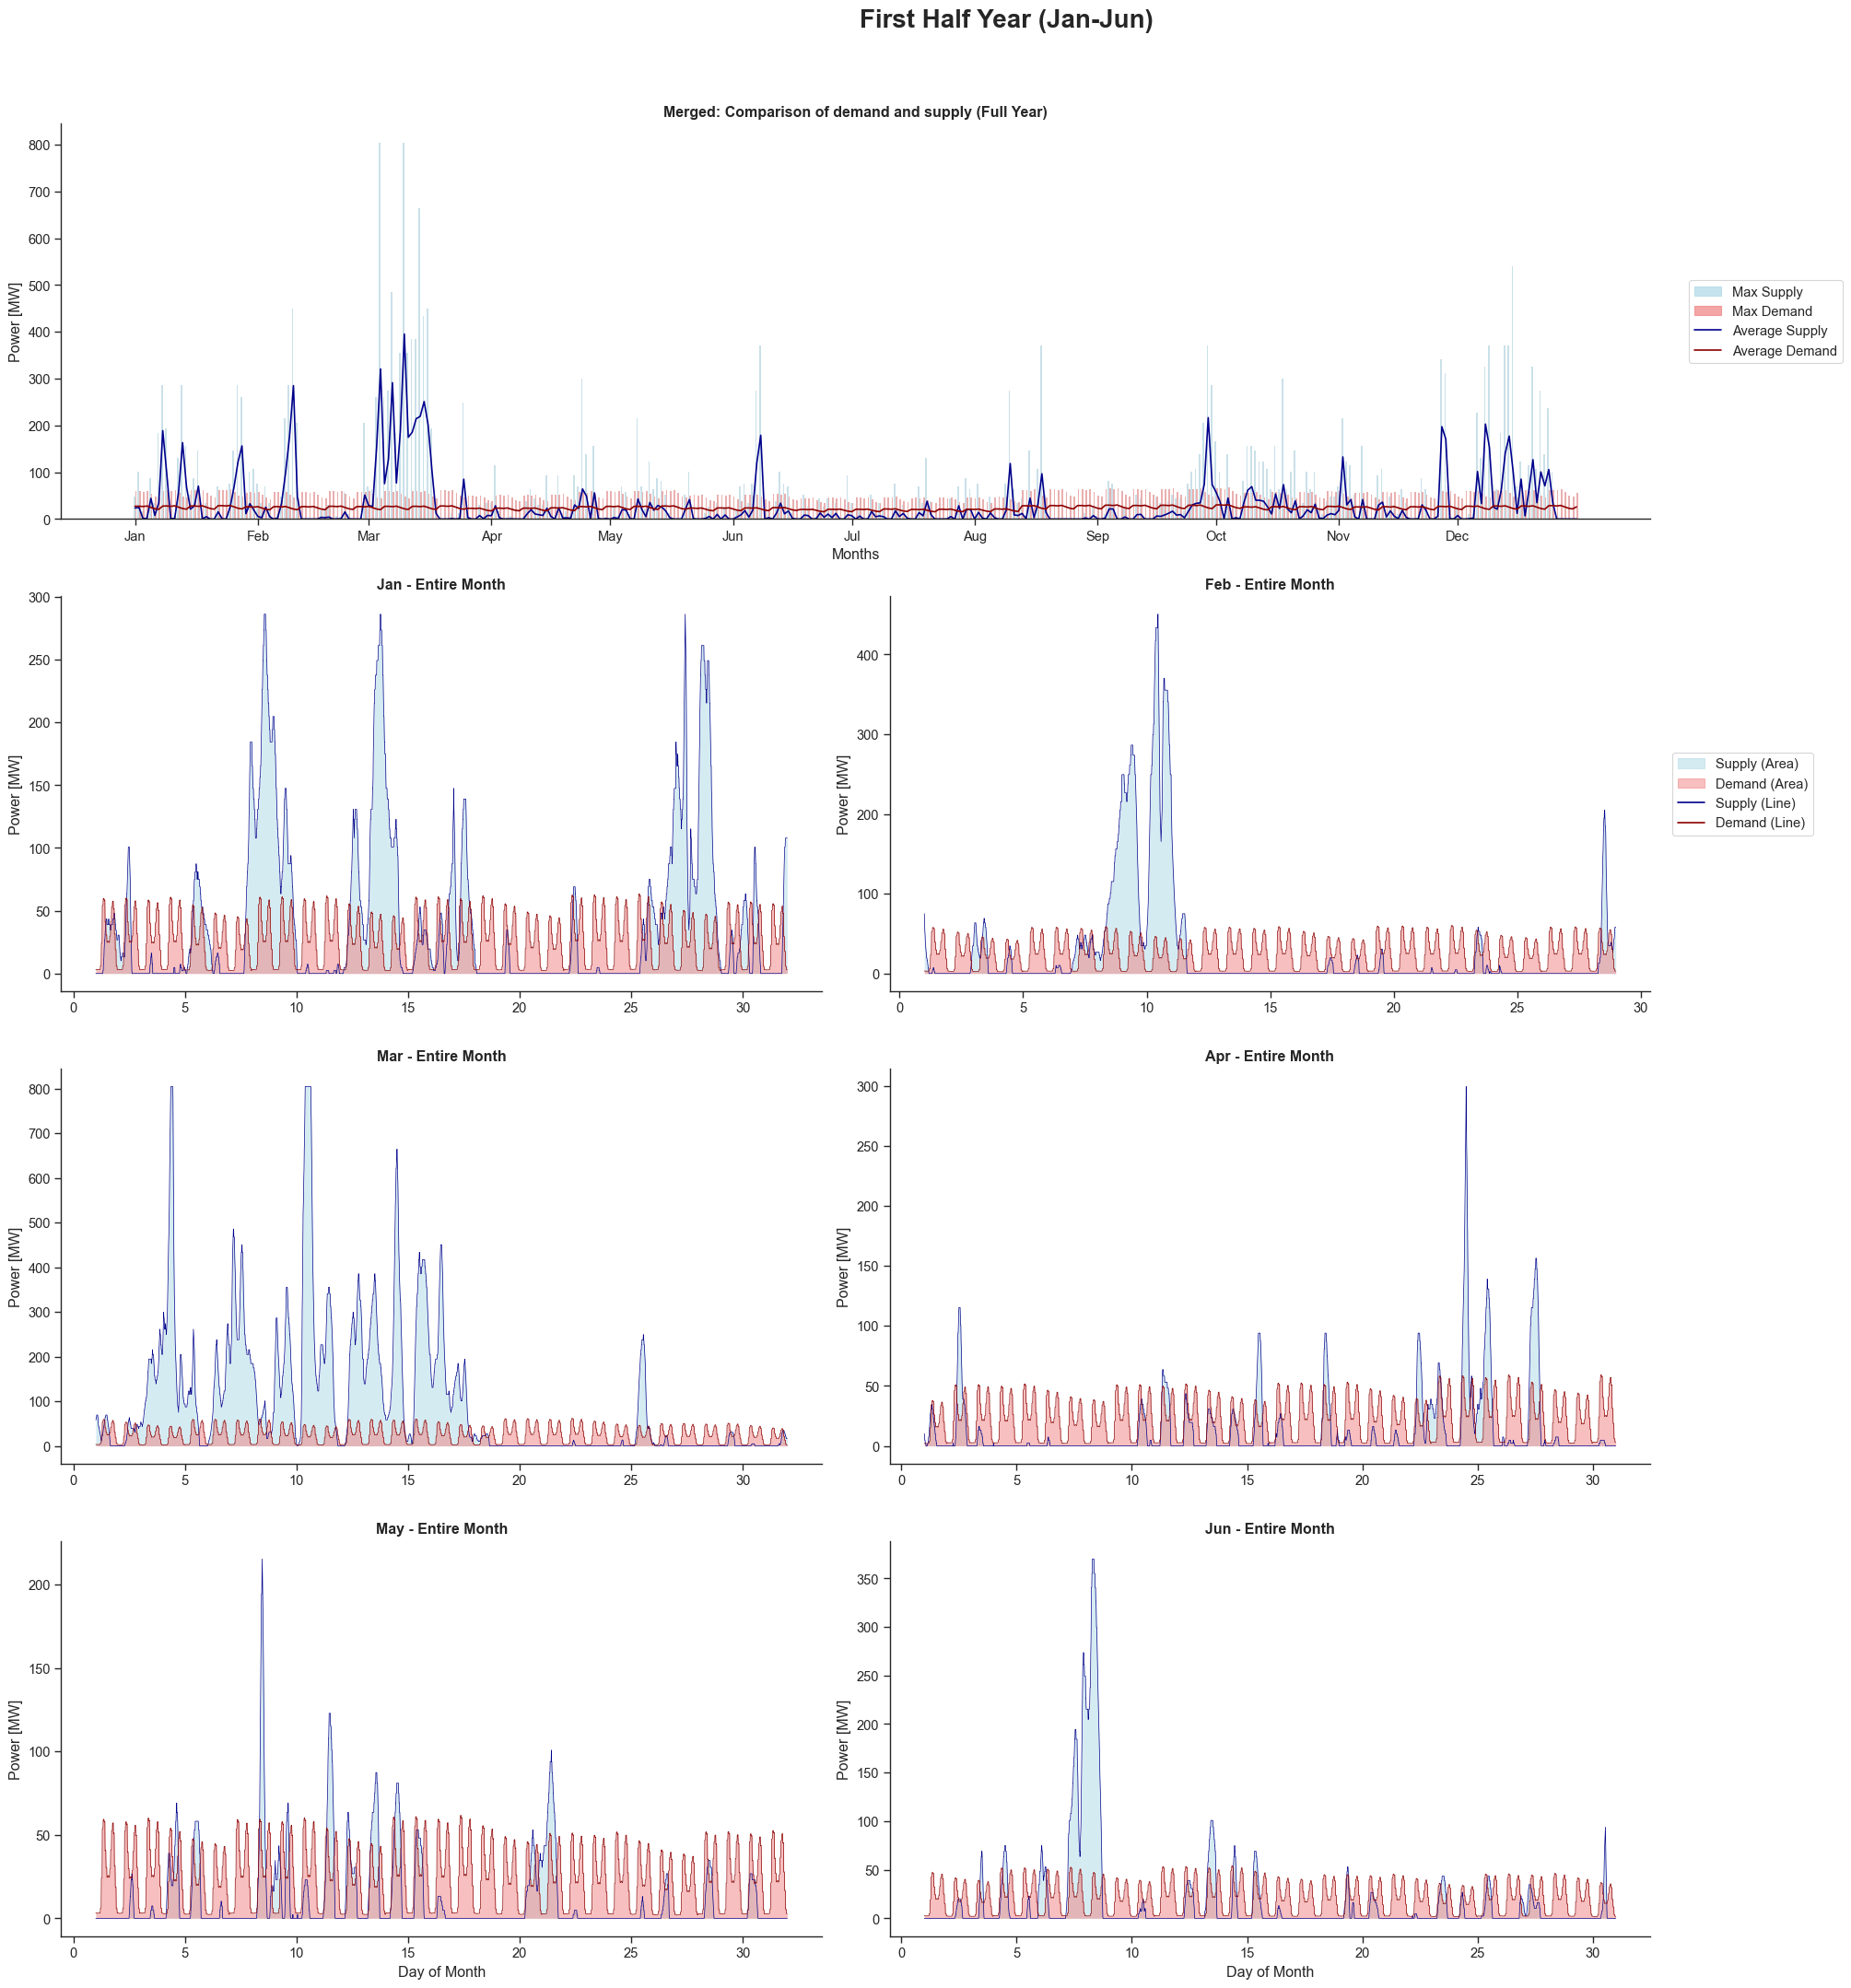

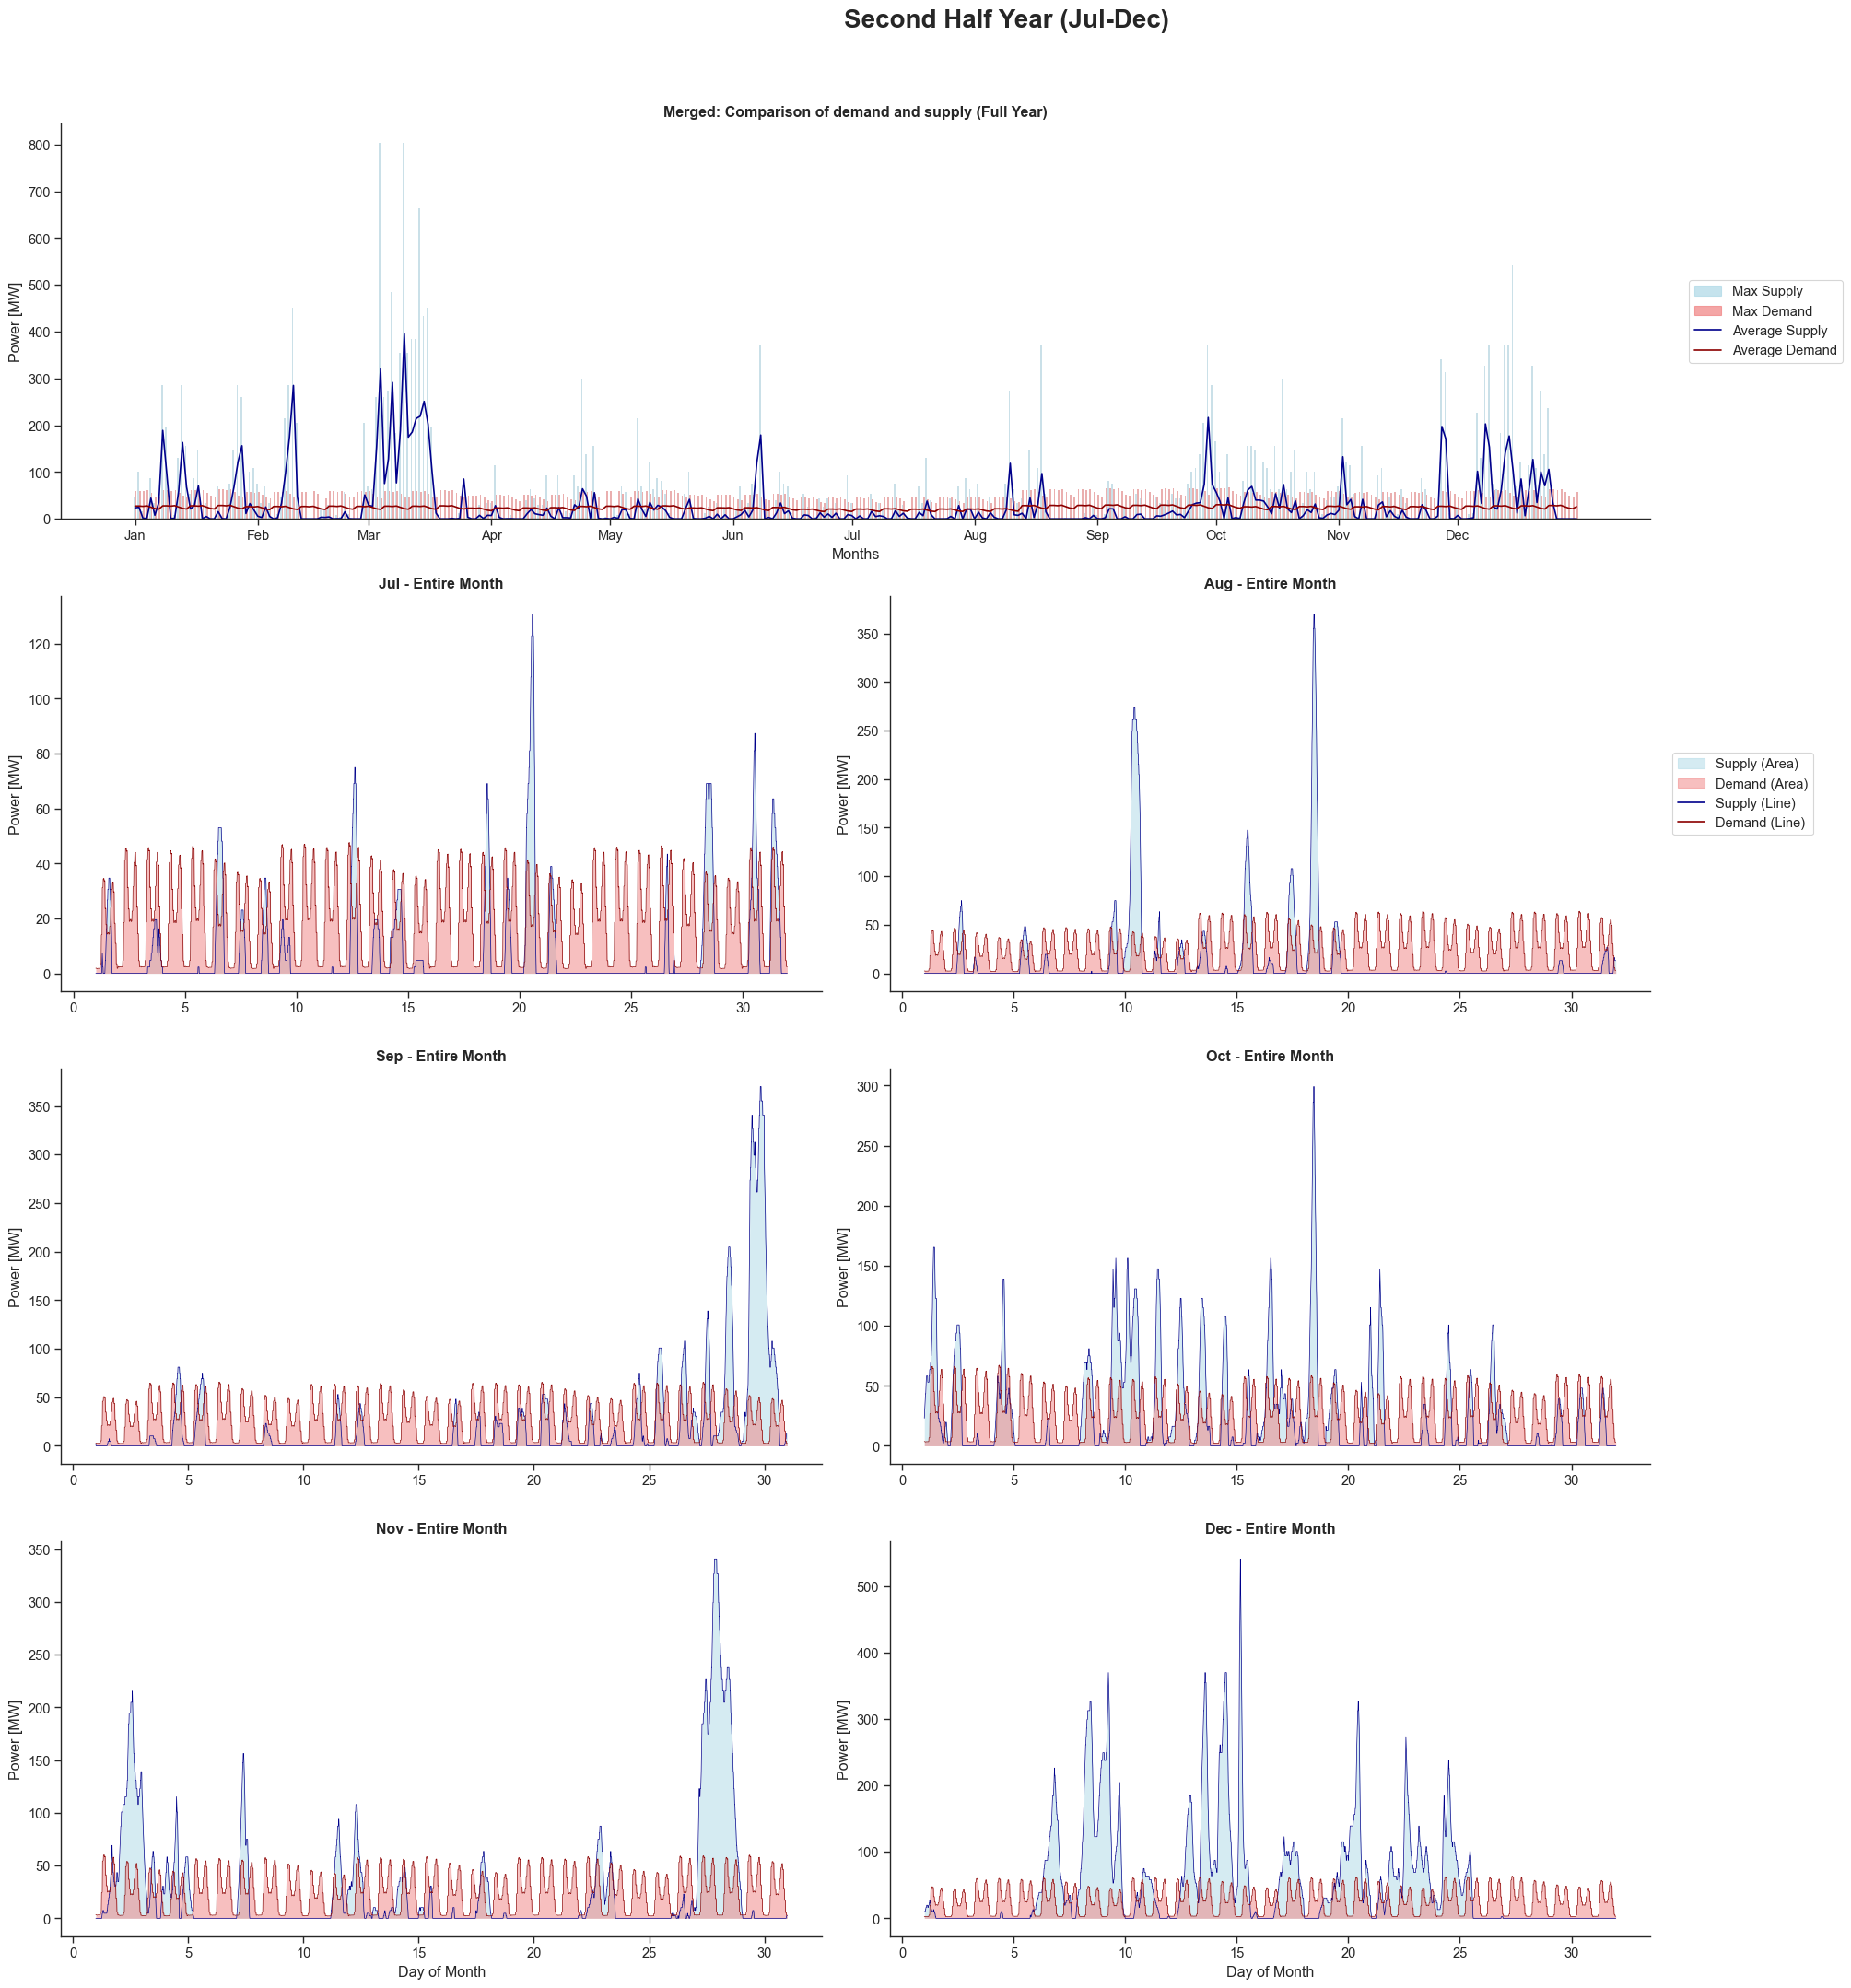

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Apply academic style using Seaborn
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# 2. Load the datasets
df_supply = pd.read_csv("Team38_supply.csv", skipinitialspace=True)
df_demand = pd.read_csv("Team38_demand.csv", skipinitialspace=True)

df_supply.columns = df_supply.columns.str.strip()
df_demand.columns = df_demand.columns.str.strip()

# 3. Group by discrete Days for the top overall comparison plot
df_supply['Time (Days)'] = (df_supply['time [s]'] // 86400).astype(int)
df_demand['Time (Days)'] = (df_demand['time [s]'] // 86400).astype(int)

supply_agg = df_supply.groupby('Time (Days)', observed=False)['power [MW]'].agg(Mean='mean', Max='max').reset_index()
demand_agg = df_demand.groupby('Time (Days)', observed=False)['power [MW]'].agg(Mean='mean', Max='max').reset_index()

supply_agg['Type'] = 'Supply'
demand_agg['Type'] = 'Demand'
merged_agg = pd.concat([supply_agg, demand_agg], ignore_index=True)

month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def create_half_year_figure_entire_month(month_indices, fig_title):
    # Enlarge the plot to make it clear for the entire month
    fig = plt.figure(figsize=(22, 22))
    gs = fig.add_gridspec(4, 2)
    
    # --- Top Subplot: Full Year Comparison ---
    ax_top = fig.add_subplot(gs[0, :])
    
    sns.barplot(data=merged_agg, x='Time (Days)', y='Max', hue='Type', palette={'Supply': 'lightblue', 'Demand': 'lightcoral'}, alpha=0.7, linewidth=0, ax=ax_top)
    sns.lineplot(data=merged_agg, x='Time (Days)', y='Mean', hue='Type', palette={'Supply': 'darkblue', 'Demand': 'darkred'}, legend=False, errorbar=None, ax=ax_top)
    
    ax_top.set_title('Merged: Comparison of demand and supply (Full Year)', weight='bold')
    ax_top.set_xlabel('Months')
    ax_top.set_ylabel('Power [MW]')
    ax_top.legend(handles=[
        plt.Rectangle((0,0),1,1, color='lightblue', alpha=0.7),
        plt.Rectangle((0,0),1,1, color='lightcoral', alpha=0.7),
        plt.Line2D([], [], color='darkblue'),
        plt.Line2D([], [], color='darkred')
    ], labels=['Max Supply', 'Max Demand', 'Average Supply', 'Average Demand'], loc='center left', bbox_to_anchor=(1.02, 0.5))
    
    ax_top.set_xticks(month_starts[:-1])
    ax_top.set_xticklabels(month_names)

    # --- Small Subplots: Entire Month ---
    for i, m_idx in enumerate(month_indices):
        row = (i // 2) + 1
        col = i % 2
        ax = fig.add_subplot(gs[row, col])
        
        start_day = month_starts[m_idx]
        end_day = month_starts[m_idx+1] - 1 # Entire month
        
        # Extract entire month data for current month
        month_supply = df_supply[(df_supply['Time (Days)'] >= start_day) & (df_supply['Time (Days)'] <= end_day)]
        month_demand = df_demand[(df_demand['Time (Days)'] >= start_day) & (df_demand['Time (Days)'] <= end_day)]
        
        # Time in days (relative to day 1 of that month)
        x_supply = (month_supply['time [s]'] - start_day * 86400) / 86400.0 + 1
        x_demand = (month_demand['time [s]'] - start_day * 86400) / 86400.0 + 1
        
        # Shades under the line plot (using fill_between)
        ax.fill_between(x_supply, month_supply['power [MW]'], color='lightblue', alpha=0.5, linewidth=0)
        ax.fill_between(x_demand, month_demand['power [MW]'], color='lightcoral', alpha=0.5, linewidth=0)
        
        # Foreground lines using exact data (no averages)
        ax.plot(x_supply, month_supply['power [MW]'], color='darkblue', linewidth=0.5)
        ax.plot(x_demand, month_demand['power [MW]'], color='darkred', linewidth=0.5)
        
        ax.set_title(f'{month_names[m_idx]} - Entire Month', weight='bold')
        if i >= 4:
            ax.set_xlabel('Day of Month')
        ax.set_ylabel('Power [MW]')
        
        # Plot legend separately outside for the first plot only to represent all subplots
        if i == 1:
            ax.legend(handles=[
                plt.Rectangle((0,0),1,1, color='lightblue', alpha=0.5),
                plt.Rectangle((0,0),1,1, color='lightcoral', alpha=0.5),
                plt.Line2D([], [], color='darkblue'),
                plt.Line2D([], [], color='darkred')
            ], labels=['Supply (Area)', 'Demand (Area)', 'Supply (Line)', 'Demand (Line)'], 
               loc='center left', bbox_to_anchor=(1.02, 0.5))
            
    fig.suptitle(fig_title, weight='bold', fontsize=20)
    sns.despine(fig)
    plt.tight_layout(rect=[0, 0, 0.92, 0.96])
    plt.show()


# 4. Generate the two figures
create_half_year_figure_entire_month([0, 1, 2, 3, 4, 5], 'First Half Year (Jan-Jun)')
create_half_year_figure_entire_month([6, 7, 8, 9, 10, 11], 'Second Half Year (Jul-Dec)')

## Energy - Time

In [11]:
import scipy.integrate as integrate
import pandas as pd

def calculate_energy_metrics(df, time_col='time [s]', power_col='power [MW]', day_col='Time (Days)'):
    """
    Calculates the exact energy usage/generation using numerical integration (Trapezoidal rule).
    
    Returns:
    1. df: A copy of the original dataframe with a continuous 'Cumulative Energy [MWh]' tracker.
    2. daily_energy_df: A standalone dataframe showing exactly how much energy was used per day.
    """
    # Work on a copy to prevent overriding original data
    df = df.copy()
    
    # 1. Compute continuous Cumulative Energy E(t) across the whole timeseries
    # The output is in Megajoules (MW * seconds). We divide by 3600 to get MWh.
    cumulative_mj = integrate.cumulative_trapezoid(df[power_col], df[time_col], initial=0)
    df['Cumulative Energy [MWh]'] = cumulative_mj / 3600.0
    
    # 2. Compute exact Energy per Day using the cumulative tracker
    if day_col in df.columns:
        # Find the absolute cumulative energy at the exact end of each day
        end_of_day_cum = df.groupby(day_col, observed=False)['Cumulative Energy [MWh]'].last()
        
        # The total energy consumed IN that day is the difference from the end of the previous day
        # For the very first day, .diff() gives NaN, so we fill it with the 1st day's total cumulative value
        daily_totals = end_of_day_cum.diff().fillna(end_of_day_cum.iloc[0])
        
        # Format nicely into a pandas DataFrame
        daily_energy_df = daily_totals.reset_index()
        daily_energy_df.rename(columns={'Cumulative Energy [MWh]': 'Daily Energy [MWh]'}, inplace=True)
    else:
        daily_energy_df = None
        
    return df, daily_energy_df

# ==========================================
# HOW TO USE IT:
# ==========================================

# Run the function on your existing datasets
df_supply_integrated, supply_daily_mwh = calculate_energy_metrics(df_supply)
df_demand_integrated, demand_daily_mwh = calculate_energy_metrics(df_demand)

# Look at the numbers representing the Daily Energy [MWh] arrays:
display(supply_daily_mwh.head())
display(demand_daily_mwh.head())


,Time (Days),Daily Energy [MWh]
0,0,565.830658
1,1,598.086167
2,2,32.212105
3,3,28.556486
4,4,1056.857334


,Time (Days),Daily Energy [MWh]
0,0,657.382782
1,1,660.336773
2,2,643.751040
3,3,668.405943
4,4,601.187092


### Function Documentation: calculate_energy_metrics
Overview The calculate_energy_metrics function processes high-frequency, time-series power data to derive accurate physical energy metrics. It translates instantaneous power (in Megawatts, MW) into energy (in Megawatt-hours, MWh) by calculating the area under the power curve with respect to time. The function yields both a continuous cumulative energy tracker and a discrete daily aggregation.

Mathematical Methodology: Numerical Integration To convert power ($P$) into continuous energy ($E$), the function evaluates the definite integral over time ($t$): $$E = \int P(t) ,dt$$

Because the data consists of discretely sampled chronological points, the algorithm applies the Trapezoidal Rule for numerical integration. Rather than multiplying average power by a time duration (which essentially draws rectangular bounding boxes and introduces error), the Trapezoidal Rule calculates the area under the curve by drawing straight linear segments between every consecutive data point. This method dynamically accounts for any exact gaps or variations in the $\Delta t$ bounds of the dataset.

Algorithmic Approach & Implementation The function relies on highly optimized, vectorized operations via SciPy and Pandas through a two-step mathematical approach:

Continuous Cumulative Integration (SciPy) First, the code executes a continuous running trace of the integral across the entire dataset using scipy.integrate.cumulative_trapezoid.

Unit Conservation: Integrating Megawatts (MJ/s) over an array of seconds natively results in Megajoules (MJ). The algorithm divides the resultant continuous array by 3,600 to cleanly transform the measurement into the standard industry unit of Megawatt-hours (MWh).
Lossless Discrete Interval Extraction (Pandas) A common flaw in grouping time-series data by specific intervals (like days) before integrating is "boundary loss"—the subtle mathematical area dropped between the final timestamp of Day 1 and the very first timestamp of Day 2 is skipped by the integrator.

The Solution: The function circumvents boundary loss by leveraging the complete running total from Step 1. It extracts the absolute Cumulative Energy strictly at the final index of each day, and computes the finite difference (diff()) between sequential days. By subtracting the cumulative total of the previous day from the current day, the algorithm guarantees perfect mathematical continuity, ensuring exactly zero energy is lost between grouping boundaries.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8916\2532137050.py:75: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, linestyle='--', alpha=0.5)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_8916\2532137050.py:75: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, linestyle='--', alpha=0.5)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_8916\2532137050.py:75: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, linestyle='--', alpha=0.5)


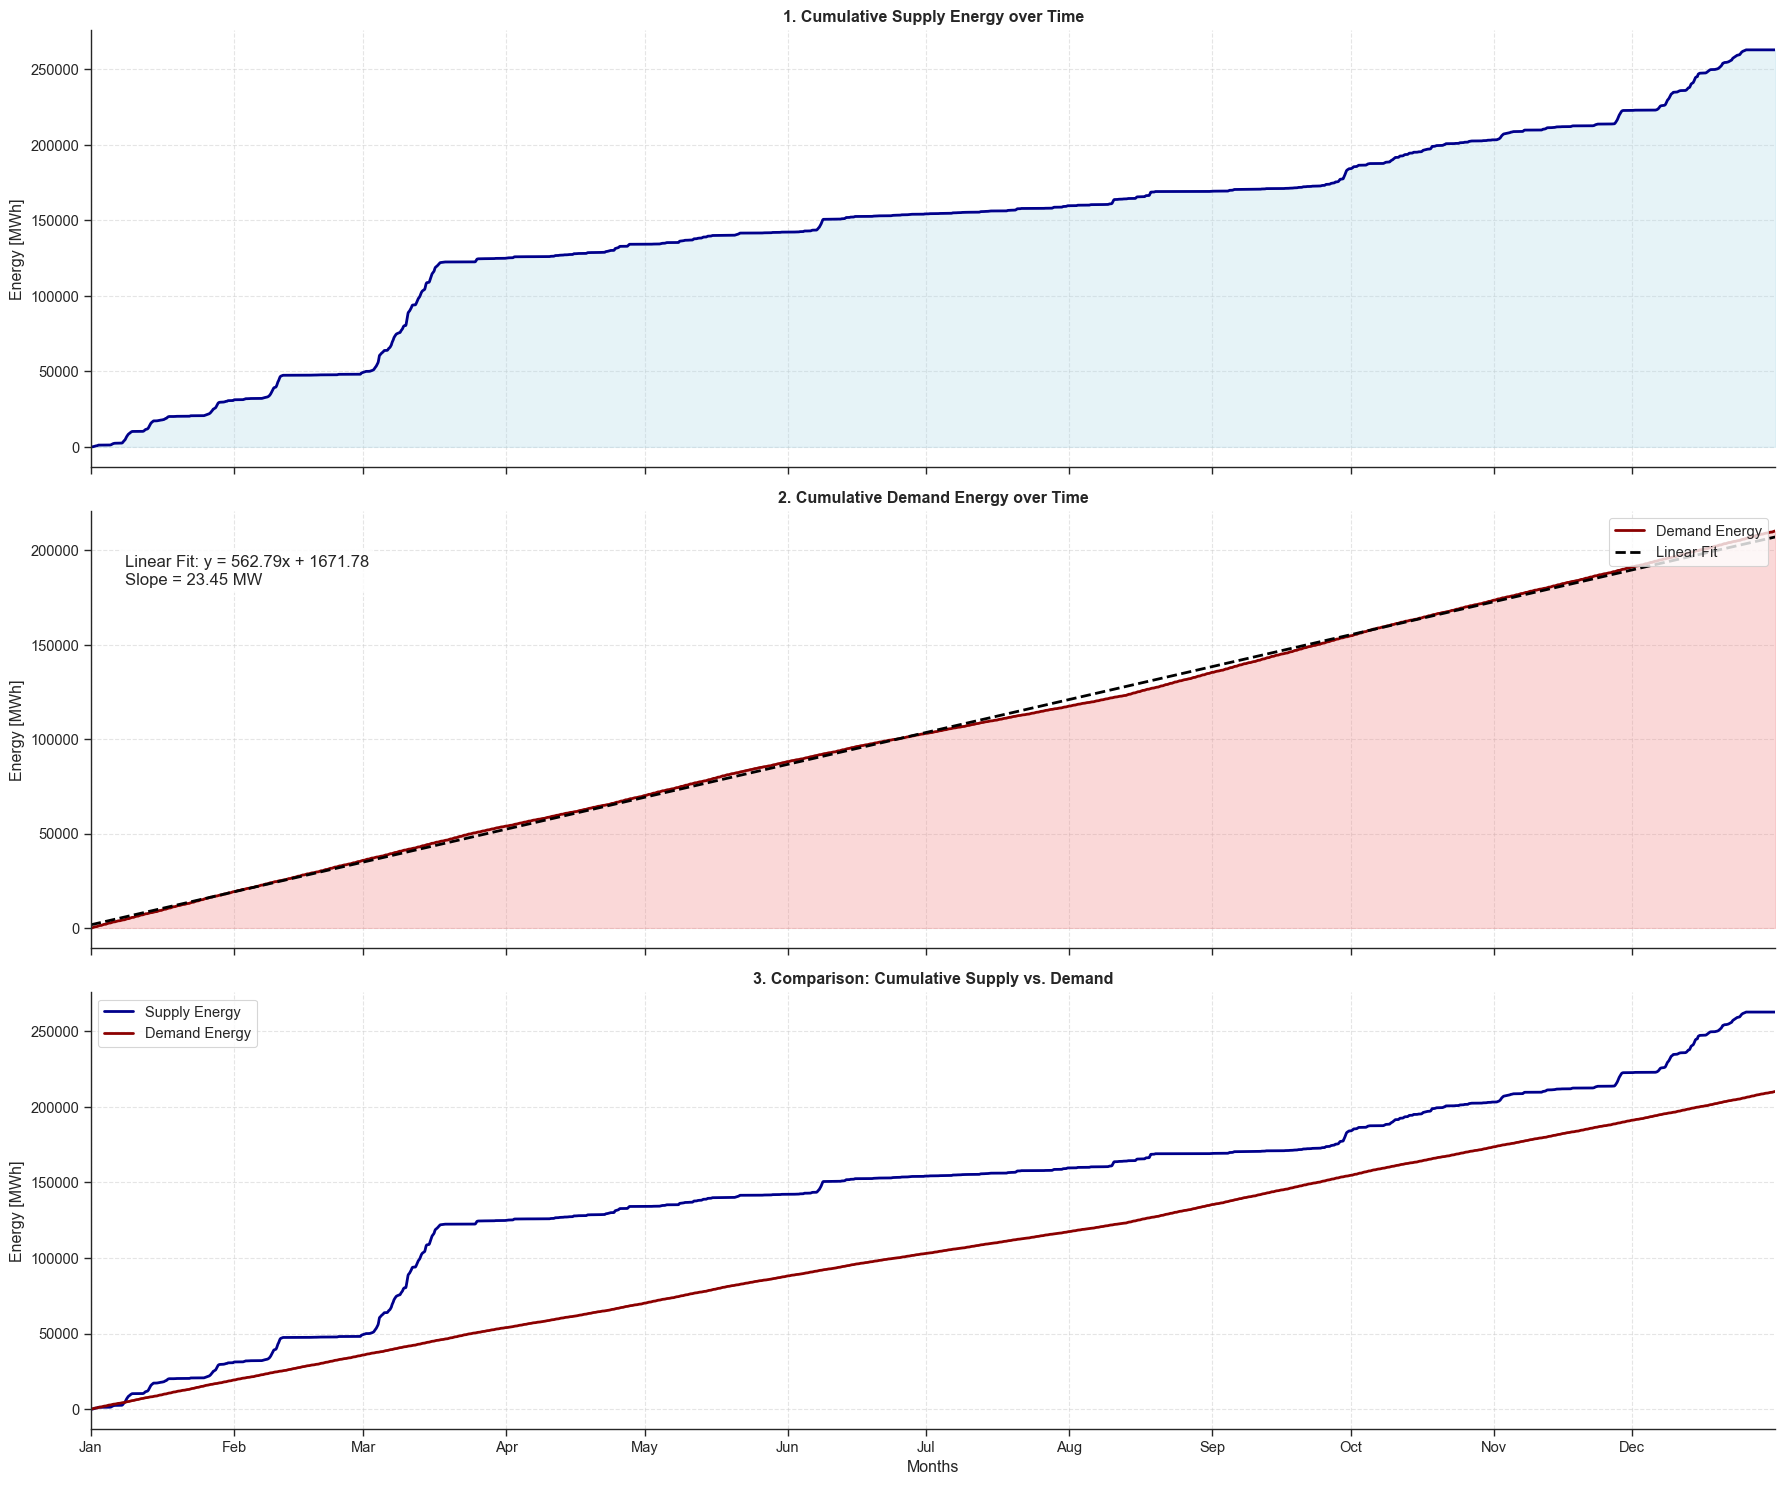

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import numpy as np

# 1. Apply academic style using Seaborn
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# 2. Load the datasets 
df_supply = pd.read_csv("Team38_supply.csv", skipinitialspace=True)
df_demand = pd.read_csv("Team38_demand.csv", skipinitialspace=True)

# Clean spaces from columns just in case
df_supply.columns = df_supply.columns.str.strip()
df_demand.columns = df_demand.columns.str.strip()

# 3. Calculate exact Cumulative Energy inside the dataset
df_supply['Cumulative Energy [MWh]'] = integrate.cumulative_trapezoid(df_supply['power [MW]'], df_supply['time [s]'], initial=0) / 3600.0
df_demand['Cumulative Energy [MWh]'] = integrate.cumulative_trapezoid(df_demand['power [MW]'], df_demand['time [s]'], initial=0) / 3600.0

# Create a continuous "Days" column for accurate physical x-axis plotting across the year
df_supply['Continuous Time (Days)'] = df_supply['time [s]'] / 86400.0
df_demand['Continuous Time (Days)'] = df_demand['time [s]'] / 86400.0

# Fit a linear function to the demand curve using np.polyfit (degree=1)
slope, intercept = np.polyfit(df_demand['Continuous Time (Days)'], df_demand['Cumulative Energy [MWh]'], 1)
df_demand['Linear Fit [MWh]'] = slope * df_demand['Continuous Time (Days)'] + intercept

# Convert slope from MWh/day to MW (divide by 24 hours)
slope_mw = slope / 24.0

month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 4. Generate the 3-subplot Graph
def create_energy_time_figure():
    fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=True)
    
    # --- Subplot 1: Supply Energy-Time ---
    axes[0].plot(df_supply['Continuous Time (Days)'], df_supply['Cumulative Energy [MWh]'], color='darkblue', linewidth=2)
    axes[0].set_title('1. Cumulative Supply Energy over Time', weight='bold')
    axes[0].set_ylabel('Energy [MWh]')
    axes[0].fill_between(df_supply['Continuous Time (Days)'], df_supply['Cumulative Energy [MWh]'], color='lightblue', alpha=0.3)
    
    # --- Subplot 2: Demand Energy-Time ---
    axes[1].plot(df_demand['Continuous Time (Days)'], df_demand['Cumulative Energy [MWh]'], color='darkred', linewidth=2, label='Demand Energy')
    # Plot the fitted linear regression line
    axes[1].plot(df_demand['Continuous Time (Days)'], df_demand['Linear Fit [MWh]'], color='black', linestyle='--', linewidth=2, label='Linear Fit')
    axes[1].set_title('2. Cumulative Demand Energy over Time', weight='bold')
    axes[1].set_ylabel('Energy [MWh]')
    axes[1].fill_between(df_demand['Continuous Time (Days)'], df_demand['Cumulative Energy [MWh]'], color='lightcoral', alpha=0.3)
    
    # Write the equation and slope (in MW) onto the subplot
    textstr = f'Linear Fit: y = {slope:.2f}x + {intercept:.2f}\nSlope = {slope_mw:.2f} MW'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    axes[1].text(0.02, 0.90, textstr, transform=axes[1].transAxes, fontsize=12,
                 verticalalignment='top', bbox=props)
    
    axes[1].legend(loc='upper right')
    
    # --- Subplot 3: Comparison of the two ---
    axes[2].plot(df_supply['Continuous Time (Days)'], df_supply['Cumulative Energy [MWh]'], color='darkblue', linewidth=2, label='Supply Energy')
    axes[2].plot(df_demand['Continuous Time (Days)'], df_demand['Cumulative Energy [MWh]'], color='darkred', linewidth=2, label='Demand Energy')
    axes[2].set_title('3. Comparison: Cumulative Supply vs. Demand', weight='bold')
    axes[2].set_xlabel('Months')
    axes[2].set_ylabel('Energy [MWh]')
    axes[2].legend(loc='upper left')
    
    # Unify formatting: ticks, grid, and borders
    for ax in axes:
        ax.set_xlim(0, 365)
        ax.set_xticks(month_starts)
        ax.set_xticklabels(month_names)
        ax.grid(False, linestyle='--', alpha=0.5)
        sns.despine(ax=ax)
        
    plt.tight_layout()
    plt.show()

# Run the function
create_energy_time_figure()



